In [4]:
#Monthly Job Postings for Top Data Jobs in the US
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [143]:
#Top 5 skills for Data Analyst per month
df_exploded = df.explode('job_skills').copy()

In [72]:
#get the month date of job_posted_date
df_exploded['job_posted_month'] = df_exploded['job_posted_date'].dt.strftime('%B')
df_exploded

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None,June
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,r,"{'analyst_tools': ['power bi', 'tableau'], 'pr...",January
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,python,"{'analyst_tools': ['power bi', 'tableau'], 'pr...",January
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,sql,"{'analyst_tools': ['power bi', 'tableau'], 'pr...",January
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,nosql,"{'analyst_tools': ['power bi', 'tableau'], 'pr...",January
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,None,NaN,NaN,Capital One,kafka,"{'cloud': ['aws', 'snowflake', 'azure', 'redsh...",March
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,None,NaN,NaN,Capital One,kubernetes,"{'cloud': ['aws', 'snowflake', 'azure', 'redsh...",March
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,None,NaN,NaN,Capital One,docker,"{'cloud': ['aws', 'snowflake', 'azure', 'redsh...",March
785740,Software Engineer,AWS System Analyst,India,melalui Trigyn,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,None,NaN,NaN,Trigyn,aws,"{'cloud': ['aws'], 'other': ['flow']}",March


In [141]:
df_exploded_pivot = df_exploded.pivot_table(index=['job_title_short','job_posted_month'], columns='job_skills', aggfunc='size', fill_value=0)
job_title = 'Data Analyst'
df_exploded_pivot = df_exploded_pivot.loc[job_title]
df_exploded_pivot = df_exploded_pivot.reset_index()
df_exploded_pivot['num_month'] = pd.to_datetime(df_exploded_pivot['job_posted_month'], format="%B").dt.month
df_exploded_pivot = df_exploded_pivot.set_index(keys='num_month').sort_values(by='num_month', ascending=True)
df_exploded_pivot = df_exploded_pivot.set_index(keys='job_posted_month')
df_exploded_pivot.loc['Total'] = df_exploded_pivot.sum()

#top skills for all data jobs
#top_skills = df_exploded.groupby(by='job_skills').size().sort_values(ascending=False).head().index
#top_skills
df_exploded_pivot = df_exploded_pivot[df_exploded_pivot.loc['Total'].sort_values(ascending=False).index]
df_exploded_pivot = df_exploded_pivot.drop('Total')

#df_exploded_pivot['num_month'] = df_exploded_pivot['job_posted_month'].s
#df_exploded_pivot = df_exploded.groupby(by=['job_posted_month', 'job_title_short', 'job_skills']).size()
#df_exploded_pivot = df_exploded_pivot.reset_index()
#df_exploded_pivot[df_exploded_pivot['job_title_short'] == 'Data Analyst']


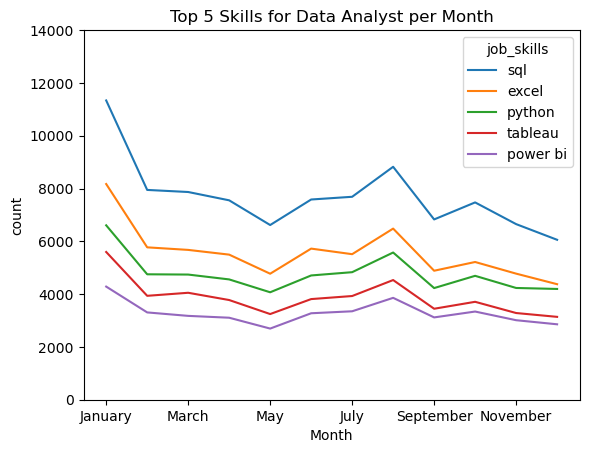

In [142]:
#plotting Top 5 Skills for Data Analyst per Month
df_exploded_pivot.iloc[:,:5].plot(kind='line')
plt.title(f'Top 5 Skills for {job_title} per Month')
plt.ylabel('count')
plt.xlabel('Month')
plt.ylim(0, 14000)
plt.show()